# Importing Libraries

In [1]:
import sys
from pathlib import Path
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
import seaborn as sns

# Loading Datset

In [ ]:
sys.path.append(str(Path().resolve().parents[1]))
from dm_classif.config import RAW_DATA_DIR

import pandas as pd

# Load the CSV
file_path = RAW_DATA_DIR / "raw_diabetes_data.csv"
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


# Bivariate and Multivariate Analysis

In [4]:
df_no = df[df['Diabetes_binary'] == 0]
df_yes = df[df['Diabetes_binary'] == 1]

### Gender Distribution for no-diabetes and diabetes

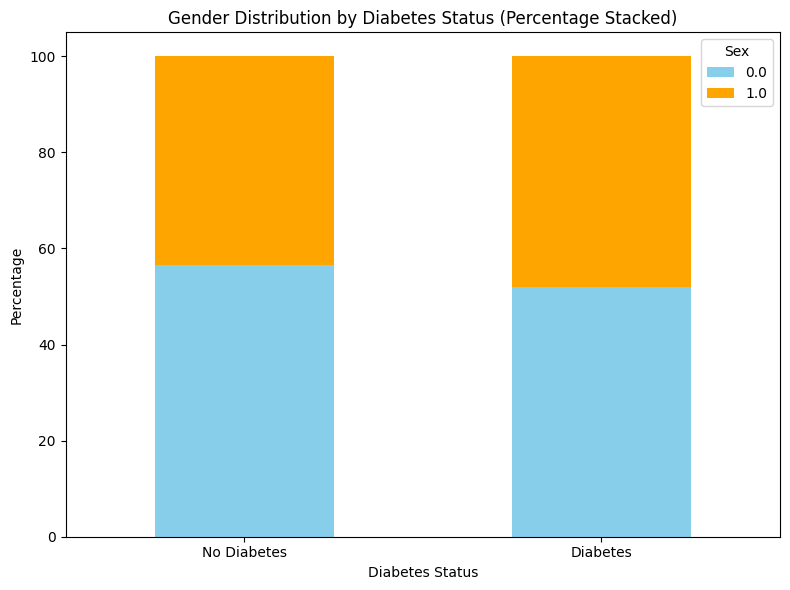

In [8]:
stacked_data = (
    df.groupby(['Diabetes_binary', 'Sex']).size()
    .unstack()
    .rename(index={0: 'No Diabetes', 1: 'Diabetes'})
)

stacked_percent = stacked_data.div(stacked_data.sum(axis=1), axis=0) * 100

stacked_percent.plot(
    kind='bar',
    stacked=True,
    color=['skyblue', 'orange'],
    figsize=(8, 6)
)

plt.title('Gender Distribution by Diabetes Status (Percentage Stacked)')
plt.xlabel('Diabetes Status')
plt.ylabel('Percentage')
plt.xticks(rotation=0)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()



### Distribution of Diabetes across ages

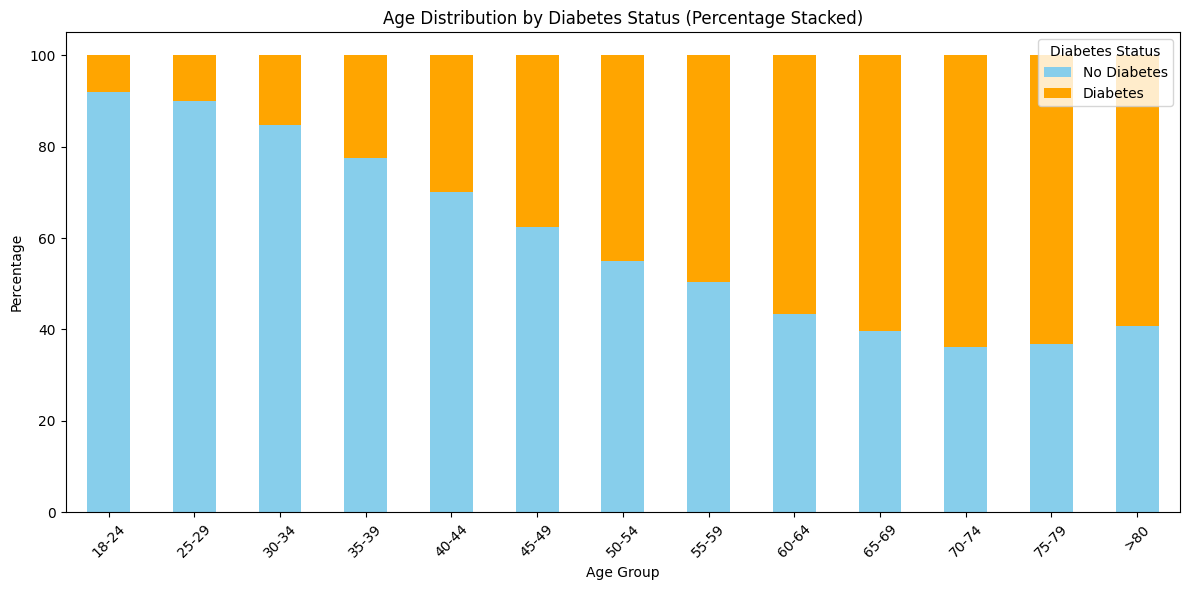

In [20]:
age_diabetes_counts = (
    df.groupby(['Age', 'Diabetes_binary']).size()
    .unstack(fill_value=0)
    .rename(columns={0: 'No Diabetes', 1: 'Diabetes'})
)
age_diabetes_percent = age_diabetes_counts.div(age_diabetes_counts.sum(axis=1), axis=0) * 100
ax= age_diabetes_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    color=['skyblue', 'orange']
)
age_labels = [
    '18-24', '25-29', '30-34', '35-39', '40-44',
    '45-49', '50-54', '55-59', '60-64',
    '65-69', '70-74', '75-79', '>80'
]
plt.title('Age Distribution by Diabetes Status (Percentage Stacked)')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
ax.set_xticklabels(age_labels, rotation=45)
plt.legend(title='Diabetes Status')
plt.tight_layout()
plt.show()


### BMI distribution for diabetic and non-diabetic people

(15.0, 60.0)

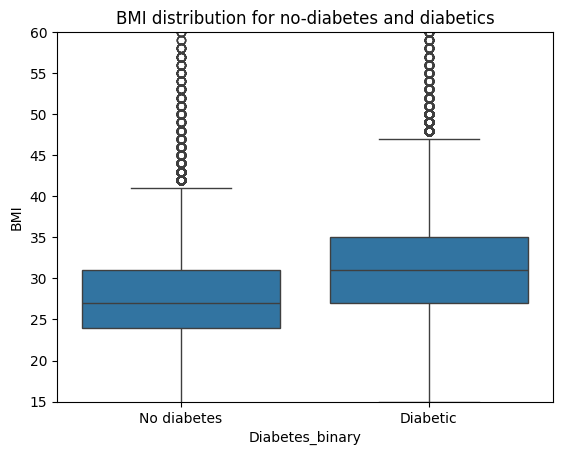

In [18]:
ax = sns.boxplot(data=df, x='Diabetes_binary', y='BMI')
ax.set(title = 'BMI distribution for no-diabetes and diabetics')
ax.set_xticks(ax.get_xticks()) 
ax.set_xticklabels(['No diabetes', 'Diabetic'])
plt.ylim(15, 60)

### Comparing Diabetic and Non-diabetic people for High cholestrol, High BP, smoking habits, Alcohol consumption, physical activity and difficulty in walking.

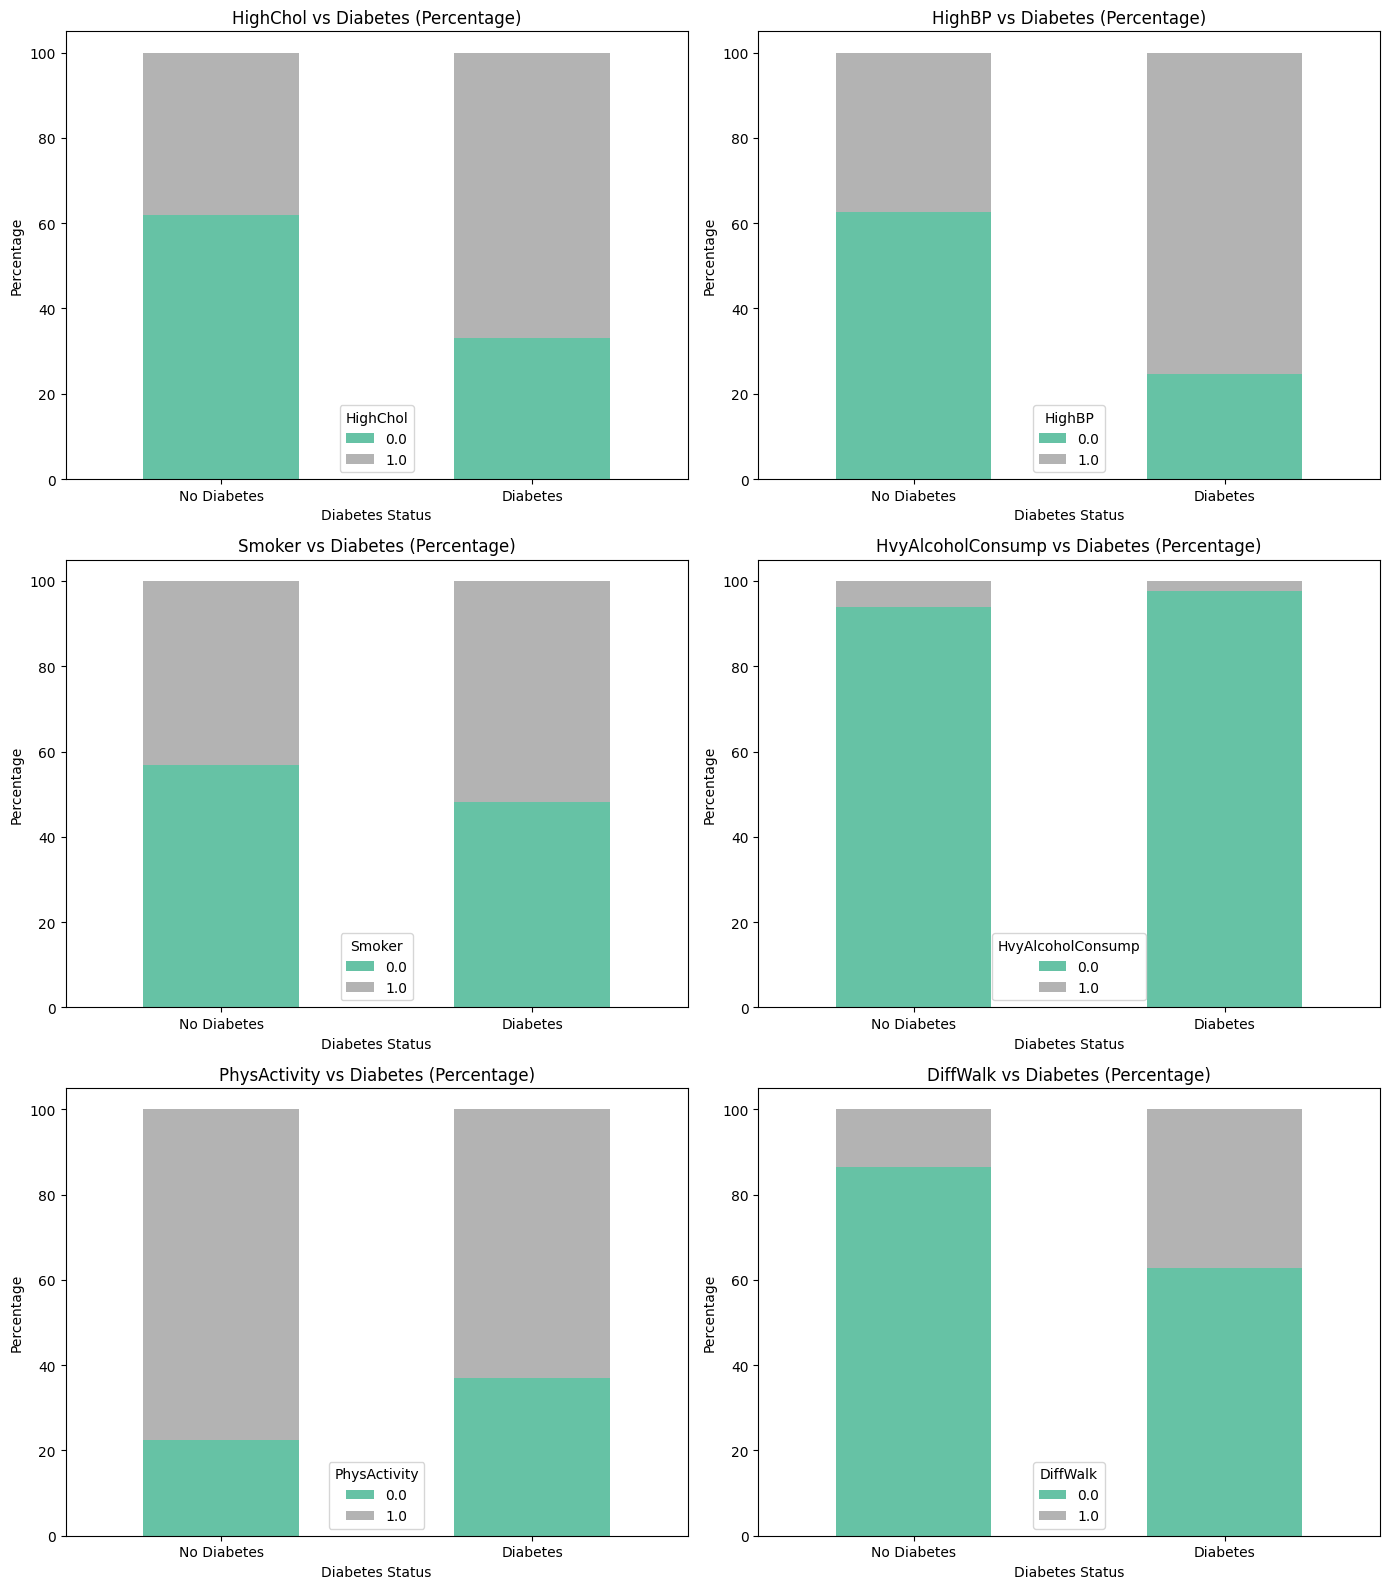

In [28]:
col_names = ['HighChol', 'HighBP', 'Smoker', 'HvyAlcoholConsump', 'PhysActivity', 'DiffWalk']

fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(col_names):
    counts = pd.crosstab(df['Diabetes_binary'], df[col])
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    percentages.plot(kind='bar', stacked=True, ax=axes[i], colormap='Set2')

    axes[i].set_title(f'{col} vs Diabetes (Percentage)')
    axes[i].set_xlabel('Diabetes Status')
    axes[i].set_ylabel('Percentage')
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=0)
    axes[i].legend(title=col)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Observations

1. Diabetes **affects both females and males**.
2. The **chances** of having Diabetes **increases** with **Age**.
3. Individuals with diabetes often have a **higher Body Mass Index** (BMI).
4. Diabetes is frequently associated with **elevated cholesterol levels and high blood pressure**.
5. People with diabetes often report **reduced physical activity and difficulty walking**.
6. **Smoking** and **alcohol consumption** have **little impact** on diabetes status.
7. Key factors linked to diabetes include **general health, high blood pressure, high cholesterol, BMI, walking difficulties, and age**.